# Análisis BETO - Reseñas Turísticas de Costa Rica

**Proyecto 2: Análisis Semántico de Reseñas**

Este notebook usa BETO (Spanish BERT) para análisis contextuales profundos de las reseñas.

## 1. Setup y configuración

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import torch
import pickle
import warnings
warnings.filterwarnings('ignore')

# Importar módulos personalizados
from preprocessing import load_corpus
from beto_utils import (
    BETOEmbedder, BETOAnalyzer, BETOLanguageModel, BETOVisualizer,
    save_embeddings, load_embeddings
)

# Configurar visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Detectar dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✓ Usando dispositivo: {device}")
print(f"✓ Librerías importadas correctamente")

✓ Usando dispositivo: cpu
✓ Librerías importadas correctamente


## 2. Cargar corpus

In [2]:
# Cargar corpus
df = load_corpus('../data/corpus.csv')

# Mostrar ejemplos
print("\nEjemplos de reseñas:")
for idx, row in df.head(3).iterrows():
    print(f"\n  Calificación: {row['calificacion']}⭐")
    print(f"  Tipo: {row['tipo_lugar']}")
    print(f"  Texto: {row['texto'][:150]}...")

Corpus cargado: 2116 reseñas
Columnas: ['texto', 'calificacion', 'tipo_lugar', 'fuente', 'fecha', 'lugar', 'polaridad']
Tipos de lugar: <StringArray>
['parque', 'restaurante', 'hotel']
Length: 3, dtype: str
Rango de calificaciones: 1.0-5.0

Ejemplos de reseñas:

  Calificación: 5.0⭐
  Tipo: parque
  Texto: Tour fabuloso, bellísimo el bosque nuboso de Monteverde con el circuito de los puentes colgantes. Tras el almuerzo visitamos el ranario de la zona, do...

  Calificación: 4.0⭐
  Tipo: parque
  Texto: Vale la pena ir a ver los puentes colgantes de monteverde, son muy bonitos....

  Calificación: 4.0⭐
  Tipo: parque
  Texto: La actividad es muy bonita, sin embargo hay dos cosas a tener en cuenta: el trayecto se hace eterno (4 horas de ida y 4 horas de vuelta), y el Serpent...


## 3. Generar embeddings BETO

In [3]:
# Inicializar BETO
embedder = BETOEmbedder(
    model_name="dccuchile/bert-base-spanish-wwm-cased",
    device=device
)

Cargando dccuchile/bert-base-spanish-wwm-cased...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ BETO cargado en cpu
  Parámetros: 109,850,880
  Dimensión: 768


In [4]:
# Generar embeddings para todas las reseñas
# Nota: Esto puede tardar 15-30 minutos en CPU, 2-5 minutos en GPU

print(f"Generando embeddings para {len(df)} reseñas...")
print("(Esto puede tardar varios minutos)\n")

beto_embeddings = embedder.embed_batch(
    df['texto'].tolist(),
    use_cls=True,
    batch_size=32
)

print(f"\n✓ Embeddings generados: {beto_embeddings.shape}")
print(f"  Dimensiones: {beto_embeddings.shape[1]}")
print(f"  Documentos: {beto_embeddings.shape[0]}")

Generando embeddings para 2116 reseñas...
(Esto puede tardar varios minutos)



Generando embeddings: 100%|██████████| 67/67 [05:50<00:00,  5.22s/it]



✓ Embeddings generados: (2116, 768)
  Dimensiones: 768
  Documentos: 2116


In [5]:
# Guardar embeddings para no regenerarlos
save_embeddings(beto_embeddings, '../data/models/beto_embeddings.npy')
print("✓ Embeddings guardados para uso futuro")

✓ Embeddings guardados en ../data/models/beto_embeddings.npy
✓ Embeddings guardados para uso futuro


## 4. Crear analizador BETO

In [6]:
# Crear analizador
analyzer = BETOAnalyzer(
    embedder=embedder,
    embeddings=beto_embeddings,
    texts=df['texto'].tolist()
)

print("✓ Analizador BETO creado")

✓ Analizador BETO creado


## 5. Análisis de Polisemia

In [7]:
# Encontrar contextos de palabras polisémicas
words_to_analyze = ['planta', 'banco', 'copa', 'viaje']

print("=" * 60)
print("ANÁLISIS DE POLISEMIA CONTEXTUAL")
print("=" * 60)

for word in words_to_analyze:
    # Buscar reseñas que contengan la palabra
    mask = df['texto'].str.lower().str.contains(word, na=False)
    contexts = df[mask]['texto'].head(3).tolist()
    
    if contexts:
        print(f"\n📌 Palabra: '{word}'")
        print(f"   Encontrada en {mask.sum()} reseñas")
        
        for i, context in enumerate(contexts, 1):
            print(f"\n   Contexto {i}:")
            print(f"   {context[:200]}...")
    else:
        print(f"\n❌ '{word}': No encontrada en corpus")

ANÁLISIS DE POLISEMIA CONTEXTUAL

📌 Palabra: 'planta'
   Encontrada en 33 reseñas

   Contexto 1:
   Aunque es una excursión muy larga, unas 15 horas aproximadamente es imprescindible hacerla. El recorrido por pequeños pueblos con Sanchí, o paradas en el camino para ver plantaciones de café, hasta ll...

   Contexto 2:
   La actividad fue inmejorable. Fuimos 6 personas en furgoneta y nos hizo muy buen tiempo (supongo que el cuento cambia mucho si hace malo). Nuestro guía, Alvar, lo dió todo! Se nota que le gusta lo que...

   Contexto 3:
   Raquel como guía ha sido estupenda, con mucha conciencia y vínculo con la naturaleza. Ha sabido transmitir y compartir sus conocimientos y amor a la naturaleza. Hemos tenido suerte y pudimos disfrutar...

📌 Palabra: 'banco'
   Encontrada en 12 reseñas

   Contexto 1:
   Fuimos en auto hasta el parque, y nos tocó un día lluvioso! Tiene senderos en la naturaleza para recorrer, me gustó mucho el sendero el Ceibo! Que estás prácticamente dentro de la se

In [8]:
# Analizar similitud contextual de 'hotel' en diferentes contextos
word = 'hotel'
contexts_hotel = df[df['texto'].str.lower().str.contains(word, na=False)]['texto'].head(5).tolist()

if len(contexts_hotel) >= 2:
    print(f"\nAnalizando polisemia de '{word}'...")
    
    # Obtener embeddings contextuales
    embeddings_contexts = []
    for context in contexts_hotel:
        emb = embedder.get_sentence_embedding(context, use_cls=True)
        embeddings_contexts.append(emb)
    
    embeddings_contexts = np.array(embeddings_contexts)
    
    # Calcular similitudes
    from sklearn.metrics.pairwise import cosine_similarity
    sim_matrix = cosine_similarity(embeddings_contexts)
    
    print(f"\nMatriz de similitud entre contextos de '{word}':")
    for i in range(len(contexts_hotel)):
        for j in range(i+1, len(contexts_hotel)):
            print(f"  Contexto {i+1} - Contexto {j+1}: {sim_matrix[i,j]:.4f}")


Analizando polisemia de 'hotel'...

Matriz de similitud entre contextos de 'hotel':
  Contexto 1 - Contexto 2: 0.9152
  Contexto 1 - Contexto 3: 0.8945
  Contexto 1 - Contexto 4: 0.8536
  Contexto 1 - Contexto 5: 0.8879
  Contexto 2 - Contexto 3: 0.9175
  Contexto 2 - Contexto 4: 0.8578
  Contexto 2 - Contexto 5: 0.9022
  Contexto 3 - Contexto 4: 0.8912
  Contexto 3 - Contexto 5: 0.8777
  Contexto 4 - Contexto 5: 0.8440


## 6. Búsqueda Semántica

In [9]:
# Ejemplos de búsquedas semánticas
queries = [
    "Quiero ver naturaleza y cascadas",
    "Busco un buen servicio de comida",
    "Actividad divertida para familias",
    "Experiencia inolvidable y emocionante"
]

print("=" * 60)
print("BÚSQUEDA SEMÁNTICA")
print("=" * 60)

for query in queries:
    print(f"\n🔍 Query: \"{query}\"")
    results = analyzer.semantic_search(query, top_k=3)
    
    for rank, (idx, similarity, text) in enumerate(results, 1):
        calification = df.iloc[idx]['calificacion']
        place_type = df.iloc[idx]['tipo_lugar']
        print(f"\n   {rank}. [{similarity:.4f}] ⭐{calification} | {place_type}")
        print(f"      {text[:150]}...")

BÚSQUEDA SEMÁNTICA

🔍 Query: "Quiero ver naturaleza y cascadas"

   1. [0.9106] ⭐5.0 | parque
      Un paraíso virgen increible...

   2. [0.9056] ⭐4.0 | parque
      Pme encanta la iglesia...

   3. [0.9056] ⭐4.0 | parque
      Un lugar mágico, espiritual y natural...

🔍 Query: "Busco un buen servicio de comida"

   1. [0.8965] ⭐5.0 | hotel
      Excelente servicio todo muy delicioso...

   2. [0.8919] ⭐5.0 | parque
      Súper bien atendido excelente comida...

   3. [0.8880] ⭐5.0 | parque
      Demasiado lindo limpio, seguro y familiar...

🔍 Query: "Actividad divertida para familias"

   1. [0.8746] ⭐4.0 | hotel
      Residencias cómodas para estudiantes...

   2. [0.8690] ⭐3.0 | hotel
      Residencias aptas para estudiantes...

   3. [0.8140] ⭐5.0 | parque
      De 10! Actividad imprescindible....

🔍 Query: "Experiencia inolvidable y emocionante"

   1. [0.8840] ⭐5.0 | parque
      Bellísimo lugar para salir y disfrutar en familia...

   2. [0.8760] ⭐5.0 | parque
      Hermoso lug

## 7. Clustering de Reseñas

In [10]:
# Determinar número óptimo de clusters
print("Calculando silhouette scores para diferentes números de clusters...\n")

silhouette_scores = []
n_clusters_range = range(2, 11)

for n in n_clusters_range:
    labels, _ = analyzer.clustering(n_clusters=n)
    score = silhouette_score(beto_embeddings, labels)
    silhouette_scores.append(score)
    print(f"  n_clusters={n}: silhouette_score={score:.4f}")

optimal_clusters = n_clusters_range[np.argmax(silhouette_scores)]
print(f"\n✓ Número óptimo de clusters: {optimal_clusters}")

Calculando silhouette scores para diferentes números de clusters...

  n_clusters=2: silhouette_score=0.0987
  n_clusters=3: silhouette_score=0.0606
  n_clusters=4: silhouette_score=0.0539
  n_clusters=5: silhouette_score=0.0586
  n_clusters=6: silhouette_score=0.0520
  n_clusters=7: silhouette_score=0.0522
  n_clusters=8: silhouette_score=0.0540
  n_clusters=9: silhouette_score=0.0482
  n_clusters=10: silhouette_score=0.0444

✓ Número óptimo de clusters: 2


In [11]:
# Realizar clustering con número óptimo
labels, kmeans = analyzer.clustering(n_clusters=optimal_clusters)

print(f"\nClustering realizado con {optimal_clusters} clusters")
print(f"Distribución de clusters:")
for i in range(optimal_clusters):
    count = (labels == i).sum()
    print(f"  Cluster {i}: {count} documentos ({100*count/len(labels):.1f}%)")


Clustering realizado con 2 clusters
Distribución de clusters:
  Cluster 0: 855 documentos (40.4%)
  Cluster 1: 1261 documentos (59.6%)


In [12]:
# Resumen de clusters
df['cluster'] = labels
cluster_summary = analyzer.get_cluster_summary(labels, top_n=2)

print("\nRESUMEN DE CLUSTERS:")
print(cluster_summary.to_string(index=False))


RESUMEN DE CLUSTERS:
 cluster  tamaño                                                                                                                                                                                            textos_representativos
       0     855                                                         Demasiado lindo el lugar, mucha paz , vista soñadas. Super recomendado... | Un lugar muy hermoso, aunque ya se empieza ver la suciedad de las personas...
       1    1261 La carretera se encuentra en buen estado para llegar con cual quier tipo de vehículo. Hay 2 parqueos... | Tiene varios senderos con todas las dificultades. El parqueo es gratis y hay que hacer reserva en la...


## 8. Masked Language Model (MLM)

In [13]:
# Inicializar modelo de lenguaje enmascarado
print("Cargando Masked Language Model...")
mlm = BETOLanguageModel()
print("✓ MLM cargado")

Cargando Masked Language Model...
Cargando pipeline de Masked LM...


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

✓ Pipeline cargado
✓ MLM cargado


In [14]:
# Crear oraciones enmascaradas del dominio turístico
oraciones_mask = [
    "El volcán Arenal es una atracción [MASK] de Costa Rica.",
    "El [MASK] fue muy amable y profesional durante todo el tour.",
    "Las aguas termales son [MASK] para relajarse después de un viaje largo.",
    "La experiencia fue [MASK] y superó todas nuestras expectativas.",
    "Los puentes colgantes son una [MASK] que no se puede perder.",
]

print("\n" + "=" * 60)
print("MASKED LANGUAGE MODEL - PREDICCIONES")
print("=" * 60)

for oracion in oraciones_mask:
    print(f"\n📝 Oración: {oracion}")
    predicciones = mlm.predict_mask(oracion, top_k=3)
    
    print(f"   Predicciones:")
    for palabra, probabilidad in predicciones:
        print(f"     → {palabra}: {probabilidad:.4f}")


MASKED LANGUAGE MODEL - PREDICCIONES

📝 Oración: El volcán Arenal es una atracción [MASK] de Costa Rica.
   Predicciones:
     → turística: 0.9866
     → natural: 0.0112
     → nacional: 0.0005

📝 Oración: El [MASK] fue muy amable y profesional durante todo el tour.
   Predicciones:
     → público: 0.3421
     → grupo: 0.2853
     → guitarrista: 0.0541

📝 Oración: Las aguas termales son [MASK] para relajarse después de un viaje largo.
   Predicciones:
     → ideales: 0.8589
     → excelentes: 0.0417
     → buenas: 0.0197

📝 Oración: La experiencia fue [MASK] y superó todas nuestras expectativas.
   Predicciones:
     → positiva: 0.2052
     → increíble: 0.0588
     → extraordinaria: 0.0543

📝 Oración: Los puentes colgantes son una [MASK] que no se puede perder.
   Predicciones:
     → propiedad: 0.0980
     → tradición: 0.0784
     → experiencia: 0.0600


## 9. Visualizaciones t-SNE

In [17]:
# Preparar t-SNE
print("Preparando proyección t-SNE...")
visualizer = BETOVisualizer(analyzer)

embeddings_tsne, texts_tsne = visualizer.prepare_tsne_data(sample_size=1000)  # Usar 1000 muestras

print("Calculando t-SNE (puede tardar)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
coords_2d = tsne.fit_transform(embeddings_tsne)

print("✓ t-SNE completado")

Preparando proyección t-SNE...
Calculando t-SNE (puede tardar)...
✓ t-SNE completado


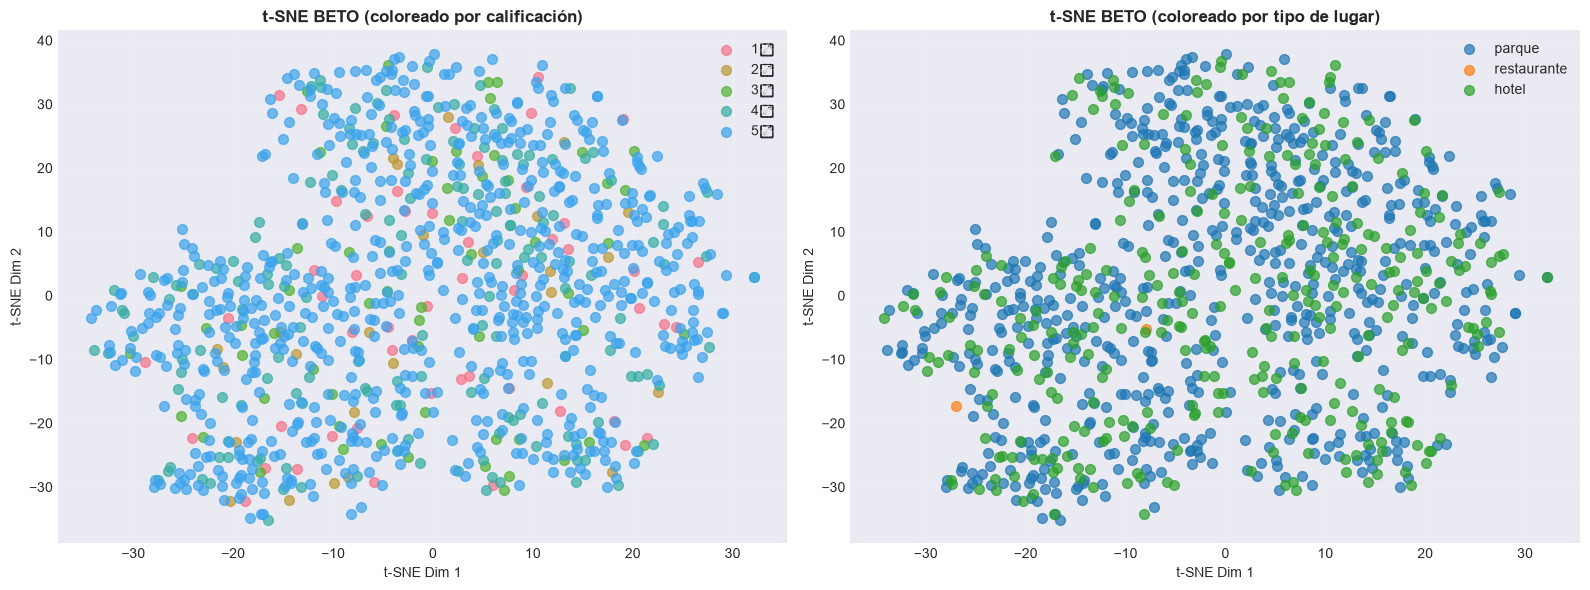

✓ Visualizaciones t-SNE completadas


In [18]:
# Crear DataFrame para visualización
df_tsne = pd.DataFrame({
    'x': coords_2d[:, 0],
    'y': coords_2d[:, 1],
    'calificacion': [df.iloc[i]['calificacion'] if i < len(df) else 0 for i in range(len(coords_2d))],
    'tipo_lugar': [df.iloc[i]['tipo_lugar'] if i < len(df) else 'Unknown' for i in range(len(coords_2d))],
    'texto': [text[:100] + '...' for text in texts_tsne]
})

# Visualizar coloreado por calificación
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por calificación
for rating in sorted(df_tsne['calificacion'].unique()):
    mask = df_tsne['calificacion'] == rating
    axes[0].scatter(df_tsne[mask]['x'], df_tsne[mask]['y'],
                   label=f"{int(rating)}⭐", s=50, alpha=0.7)

axes[0].set_title('t-SNE BETO (coloreado por calificación)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('t-SNE Dim 1')
axes[0].set_ylabel('t-SNE Dim 2')

# Por tipo de lugar
place_types = df_tsne['tipo_lugar'].unique()
colors_map = {place: plt.cm.tab10(i % 10) for i, place in enumerate(place_types)}

for place_type in place_types:
    mask = df_tsne['tipo_lugar'] == place_type
    axes[1].scatter(df_tsne[mask]['x'], df_tsne[mask]['y'],
                   label=place_type, s=50, alpha=0.7, color=colors_map[place_type])

axes[1].set_title('t-SNE BETO (coloreado por tipo de lugar)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('t-SNE Dim 1')
axes[1].set_ylabel('t-SNE Dim 2')

plt.tight_layout()
plt.show()

print("✓ Visualizaciones t-SNE completadas")

## 10. Guardar análisis

In [19]:
# Guardar datos de t-SNE
np.save('../data/visualizations/tsne_vectors_beto.npy', coords_2d)
df_tsne.to_csv('../data/analysis/beto_tsne_data.csv', index=False)

# Guardar labels de clustering
np.save('../data/models/beto_cluster_labels.npy', labels)
with open('../data/models/beto_analyzer.pkl', 'wb') as f:
    pickle.dump(analyzer, f)

# Guardar información de clustering
cluster_summary.to_csv('../data/analysis/beto_cluster_summary.csv', index=False)

print("✓ Análisis guardados")
print("  - beto_embeddings.npy")
print("  - beto_analyzer.pkl")
print("  - beto_cluster_labels.npy")
print("  - tsne_vectors_beto.npy")
print("  - beto_tsne_data.csv")
print("  - beto_cluster_summary.csv")

✓ Análisis guardados
  - beto_embeddings.npy
  - beto_analyzer.pkl
  - beto_cluster_labels.npy
  - tsne_vectors_beto.npy
  - beto_tsne_data.csv
  - beto_cluster_summary.csv


## 11. Resumen

In [20]:
print("\n" + "=" * 70)
print("RESUMEN: BETO ANALYSIS")
print("=" * 70)

print(f"\n📊 CORPUS:")
print(f"  • Total de reseñas: {len(df):,}")
print(f"  • Dimensión de embeddings BETO: 768")
print(f"  • Tipos de lugar: {df['tipo_lugar'].nunique()}")

print(f"\n🧠 ANÁLISIS CONTEXTUALES:")
print(f"  • Polisemia: Análisis de {len(words_to_analyze)} palabras polisémicas")
print(f"  • Búsqueda semántica: {len(queries)} queries de ejemplo")
print(f"  • Clustering: {optimal_clusters} clusters identificados")
print(f"  • MLM: {len(oraciones_mask)} predicciones de palabras enmascaradas")

print(f"\n📈 VISUALIZACIONES:")
print(f"  • t-SNE: {len(coords_2d)} puntos proyectados")
print(f"  • Análisis por calificación: {len(df['calificacion'].unique())} niveles")
print(f"  • Análisis por lugar: {df['tipo_lugar'].nunique()} categorías")

print(f"\n✅ ARCHIVO GENERADOS:")
print(f"  • models/beto_embeddings.npy")
print(f"  • models/beto_analyzer.pkl")
print(f"  • models/beto_cluster_labels.npy")
print(f"  • visualizations/tsne_vectors_beto.npy")
print(f"  • analysis/beto_tsne_data.csv")
print(f"  • analysis/beto_cluster_summary.csv")

print("\n" + "=" * 70)


RESUMEN: BETO ANALYSIS

📊 CORPUS:
  • Total de reseñas: 2,116
  • Dimensión de embeddings BETO: 768
  • Tipos de lugar: 3

🧠 ANÁLISIS CONTEXTUALES:
  • Polisemia: Análisis de 4 palabras polisémicas
  • Búsqueda semántica: 4 queries de ejemplo
  • Clustering: 2 clusters identificados
  • MLM: 5 predicciones de palabras enmascaradas

📈 VISUALIZACIONES:
  • t-SNE: 1000 puntos proyectados
  • Análisis por calificación: 5 niveles
  • Análisis por lugar: 3 categorías

✅ ARCHIVO GENERADOS:
  • models/beto_embeddings.npy
  • models/beto_analyzer.pkl
  • models/beto_cluster_labels.npy
  • visualizations/tsne_vectors_beto.npy
  • analysis/beto_tsne_data.csv
  • analysis/beto_cluster_summary.csv

